In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Part 1: Foundation Model Exploration (15 points)

1A. Setup and Inference (5 points)

In [2]:
pip install transformers

In [3]:
# Load the pre-trained multilingual sentiment model using HuggingFace's pipeline API:
from transformers import pipeline
sentiment = pipeline("sentiment-analysis",
  model="nlptown/bert-base-multilingual-uncased-sentiment")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [4]:
import pandas as pd

# import Olist dataset - df
df_w_comments = pd.read_csv('/content/drive/MyDrive/6545_Data_Science_and_ML_Ops/df_w_comments.csv')




In [5]:
# Filter  Olist dataset to records that have non-empty review_comment_message text.
dfwc = df_w_comments[df_w_comments['review_comment_message'].notna()]

# Sample 500 records from this filtered set (use random_state=42 for reproducibility).
df500 = dfwc.sample(n=500, random_state=42)

In [6]:
df500.shape

(500, 49)

Run the foundation model on each review comment.
The model returns a label like "3 stars" and a confidence score.

In [7]:
# convert reviews into Python list
reviews_list = df500['review_comment_message'].tolist()

# feed reviews into model
results = sentiment(reviews_list)

# print results
print(results)



[{'label': '5 stars', 'score': 0.7702049612998962}, {'label': '5 stars', 'score': 0.5968409776687622}, {'label': '1 star', 'score': 0.7025328278541565}, {'label': '2 stars', 'score': 0.4459667503833771}, {'label': '5 stars', 'score': 0.2772757112979889}, {'label': '5 stars', 'score': 0.7857320308685303}, {'label': '1 star', 'score': 0.7449882626533508}, {'label': '1 star', 'score': 0.6911635398864746}, {'label': '3 stars', 'score': 0.5004171133041382}, {'label': '5 stars', 'score': 0.7857320308685303}, {'label': '5 stars', 'score': 0.41979554295539856}, {'label': '1 star', 'score': 0.7019523978233337}, {'label': '5 stars', 'score': 0.9913826584815979}, {'label': '5 stars', 'score': 0.7999271750450134}, {'label': '1 star', 'score': 0.6384132504463196}, {'label': '5 stars', 'score': 0.4526354670524597}, {'label': '1 star', 'score': 0.7352367043495178}, {'label': '3 stars', 'score': 0.4277507960796356}, {'label': '5 stars', 'score': 0.8421036005020142}, {'label': '5 stars', 'score': 0.871

In [8]:
# convert dictionary to df
results_df = pd.DataFrame(results)
results_df.to_csv('/content/drive/MyDrive/6545_Data_Science_and_ML_Ops/sentiment_results.csv', index=False)

Map the predicted star ratings to binary: 4–5 stars → positive (1), 1–3 stars → negative (0).
This matches the same target definition from HW2.

In [9]:
# NOTE - I changed the target variable to is_negative_review because that is the
# true target feature we are trying to ID

# create an empty list
is_negative_review = []

# loop through each dictionary in results list
for item in results:

    # grab string
    label_string = item['label']

    # grab 1st character and turn into integer
    rating = int(label_string[0])

    # categorize
    if rating < 4:
      is_negative_review.append(1)
    else:
      is_negative_review.append(0)

# add to df of samples
df500['sentiment_prediction'] = is_negative_review

print(df500['sentiment_prediction'].value_counts())


sentiment_prediction
0    254
1    246
Name: count, dtype: int64


Report the class distribution of the 500-record sample: how many are actually positive vs.
negative, and how many did the foundation model predict as positive vs. negative?

In [10]:
print(df500[['sentiment_prediction', 'is_negative_review']].value_counts())


sentiment_prediction  is_negative_review
0                     0                     234
1                     1                     181
                      0                      65
0                     1                      20
Name: count, dtype: int64


In [11]:
print(df500['sentiment_prediction'].value_counts())
print(df500['is_negative_review'].value_counts())

sentiment_prediction
0    254
1    246
Name: count, dtype: int64
is_negative_review
0    299
1    201
Name: count, dtype: int64


#1B. Performance Comparison (5 points)

Create a comparison table showing the following metrics for both models, evaluated on the same
500 records:

In [12]:
import joblib

# import HW2 model
xgb_pipe = joblib.load('/content/drive/MyDrive/6545_Data_Science_and_ML_Ops/xgb_pipe.pkl')

print(xgb_pipe)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['price', 'freight_value',
                                                   'product_name_lenght',
                                                   'product_description_lenght',
                                                   'product_photos_qty',
                                                   'product_weight_g',
                                                   'product_length_cm',
                

In [13]:
# run xgb model on 500 sample & merge with sample df

# slice out is_negative_review & sentiment_prediction
X_500 = df500.drop(columns=['is_negative_review', 'sentiment_prediction'])

# generate predictions on sample
xgb_preds = xgb_pipe.predict(X_500)

# attach predictions to sample df
df500['xgb_prediction'] = xgb_preds

# print
print(df500[['is_negative_review', 'sentiment_prediction', 'xgb_prediction']].head())

        is_negative_review  sentiment_prediction  xgb_prediction
103664                   0                     0               0
76815                    0                     0               0
95866                    1                     1               1
68234                    1                     1               1
75818                    0                     0               0


In [14]:
# generate confusion matrices

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

# isolate ground truth and predictions
y_true = df500['is_negative_review']
y_pred_sent = df500['sentiment_prediction']
y_pred_xgb = df500['xgb_prediction']

# confusion matrices
cm_xgb = confusion_matrix(y_true, y_pred_xgb)
cm_sent = confusion_matrix(y_true, y_pred_sent)

print(cm_xgb)
print(cm_sent)

[[296   3]
 [ 16 185]]
[[234  65]
 [ 20 181]]


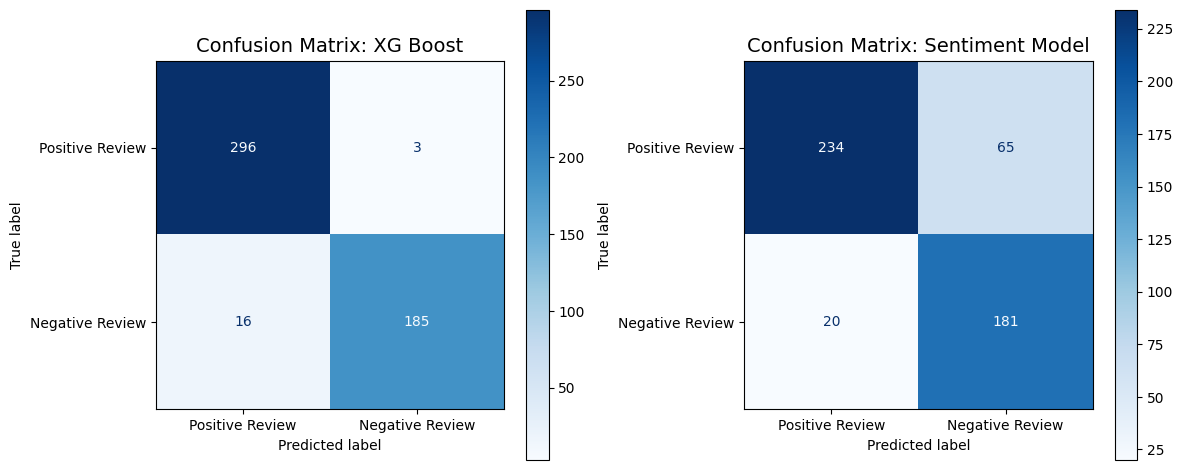


--- XGBoost Business Impact ---
True Negatives:    296 | False Positives:     3
False Negatives:    16 | True Positives:    185

--- Foundation Model Business Impact ---
True Negatives:    234 | False Positives:    65
False Negatives:    20 | True Positives:    181


In [15]:
import matplotlib.pyplot as plt

# Confusion matrix — XGB
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred_xgb,
    display_labels=['Positive Review', 'Negative Review'],
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix: XG Boost', fontsize=14)

# Confusion matrix — Sentiment
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred_sent,
    display_labels=['Positive Review', 'Negative Review'],
    cmap='Blues',
    ax=axes[1]
)
axes[1].set_title('Confusion Matrix: Sentiment Model', fontsize=14)


plt.tight_layout()
plt.show()

# 5. Print the raw metrics below the charts
print("\n--- XGBoost Business Impact ---")
tn, fp, fn, tp = confusion_matrix(y_true, y_pred_xgb).ravel()
print(f"True Negatives:  {tn:>5} | False Positives: {fp:>5}")
print(f"False Negatives: {fn:>5} | True Positives:  {tp:>5}")

print("\n--- Foundation Model Business Impact ---")
tn2, fp2, fn2, tp2 = confusion_matrix(y_true, y_pred_sent).ravel()
print(f"True Negatives:  {tn2:>5} | False Positives: {fp2:>5}")
print(f"False Negatives: {fn2:>5} | True Positives:  {tp2:>5}")

In [16]:
# create comparison table

from sklearn.metrics import roc_auc_score

# create function to calculate metrics
def get_metrics(actual, predicted):
    acc = accuracy_score(actual, predicted)
    prec = precision_score(actual, predicted)
    rec = recall_score(actual, predicted)
    f1 = f1_score(actual, predicted)
    auc = roc_auc_score(actual, predicted)
    return [acc, prec, rec, f1, auc]

# apply functions to both models
xgb_metrics = get_metrics(y_true, y_pred_xgb)
sent_metrics = get_metrics(y_true, y_pred_sent)

# display comparison table
comparison_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC'],
    'XGB Model': xgb_metrics,
    'Sentiment Model': sent_metrics
})

print(comparison_table.round(3))

      Metric  XGB Model  Sentiment Model
0   Accuracy      0.962            0.830
1  Precision      0.984            0.736
2     Recall      0.920            0.900
3   F1 Score      0.951            0.810
4        AUC      0.955            0.842


# 1C. Reflection (5 points)
Write a brief analysis (200–300 words) addressing:

●
Which model performed better on these 500 records? Why do you think that is?

●
The foundation model required zero training on Olist data. What are the advantages and
disadvantages of this zero-training approach?

●
When would you recommend using a foundation model vs. training a custom model?
Consider: data availability, task specificity, computational cost, and time-to-deployment.

●
Could these two approaches be combined in a production system? How might you use both?

My XGB model performed substantially better than the sentiment analysis model - an AUC of 0.955 vs 0.842. This is surprising to me because my model did not perform this well in training - or even as well as the sentiment model (AUC was 0.77). The sentiment model also had access to the review text that I expected would give it a huge advantage to my model, which did not even know if the customer had written a review. Perhaps the reason my model did so well is because of selection bias of only customers that leave a written review - even though it was not a feature included in the model, reviews that include a review message written are easy for my model to predict.

A disadvantage of the sentiment model's zero-training approach is that while it can apply to Portuguese, the model itself is not fine-tuned in this language. It might get some things wrong in translation. In addition, the model might be trained to expect more negative reviews than this sample contained - overall, it overpredicted negative reviews. This may be a quality of the model - in general, review comments that the model is trained on are skewed negative. People are more likely to review when they feel strongly about a product, which is often negative.

I would use a foundation model in the early stages of a project, perhaps during an EDA. I would also use it to analyze complex data as part of custom training a model, or when time is a constraint. It's a good starting point.

These 2 approaches could be combined into a production system by running the foundation model on a feature or set of features, turning that into an output such as a rating prediction and confidence score, which are then incorporated into a custom model.